# Drone Detection Dataset Analysis

This notebook characterizes the dataset structure, annotation quality, object scale, grouping, raw/augmented relationships, and leakage risk before split construction or model development.

`data/obj_det_base/` is treated as immutable source data. This analysis does not train a model or construct train/validation/test splits.

## 1. Setup and Configuration

In [1]:
from __future__ import annotations

import hashlib
import math
import random
import re
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from PIL import Image, ImageDraw, ImageFont, ImageOps

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.05,
    rc={
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}
DATASET_RELATIVE_PATH = Path("data") / "obj_det_base"
FIGURE_RELATIVE_PATH = Path("reports") / "figures"


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from a notebook or repo-root execution context."""
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / DATASET_RELATIVE_PATH).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find {DATASET_RELATIVE_PATH} from {start}")


PROJECT_ROOT = find_project_root()
DATASET_DIR = PROJECT_ROOT / DATASET_RELATIVE_PATH
FIGURE_DIR = PROJECT_ROOT / FIGURE_RELATIVE_PATH
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset directory: {DATASET_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figure output directory: {FIGURE_DIR.relative_to(PROJECT_ROOT)}")

Project root: /Users/hardefarogonondo/Personal/Projects/Software/drone-detection-and-classification-engine
Dataset directory: data/obj_det_base
Figure output directory: reports/figures


In [2]:
def save_figure(fig: plt.Figure, name: str, *, dpi: int = 300, pdf: bool = True) -> None:
    """Save figures in a report-friendly location with consistent settings."""
    png_path = FIGURE_DIR / f"{name}.png"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    if pdf:
        pdf_path = FIGURE_DIR / f"{name}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    print(f"saved: {png_path.relative_to(PROJECT_ROOT)}")


def percentile_summary(series: pd.Series, percentiles=(0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99)) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce").dropna()
    if values.empty:
        return pd.Series(dtype=float)
    summary = values.quantile(percentiles)
    summary.index = [f"p{int(p * 100):02d}" for p in percentiles]
    return pd.concat([
        pd.Series({"min": values.min()}),
        summary,
        pd.Series({"mean": values.mean(), "max": values.max()}),
    ])


def display_df(df: pd.DataFrame, caption: str | None = None) -> None:
    if caption:
        display(Markdown(f"**{caption}**"))
    display(df)

## 2. Dataset Inventory

This section recomputes core dataset counts and checks whether image and annotation stems match one-to-one.

In [3]:
all_files = sorted([p for p in DATASET_DIR.iterdir() if p.is_file()])
image_paths = sorted([p for p in all_files if p.suffix.lower() in IMAGE_EXTENSIONS])
label_paths = sorted([p for p in all_files if p.suffix.lower() == ".txt"])
other_paths = sorted([p for p in all_files if p.suffix.lower() not in IMAGE_EXTENSIONS | {".txt"}])

image_stems = Counter(p.stem for p in image_paths)
label_stems = Counter(p.stem for p in label_paths)
image_stem_set = set(image_stems)
label_stem_set = set(label_stems)

missing_labels = sorted(image_stem_set - label_stem_set)
missing_images = sorted(label_stem_set - image_stem_set)
duplicate_image_stems = {stem: count for stem, count in image_stems.items() if count > 1}
duplicate_label_stems = {stem: count for stem, count in label_stems.items() if count > 1}

empty_annotation_files = [p for p in label_paths if p.stat().st_size == 0]

inventory_df = pd.DataFrame([
    {"metric": "total files", "value": len(all_files)},
    {"metric": "image files", "value": len(image_paths)},
    {"metric": "annotation files", "value": len(label_paths)},
    {"metric": "other files", "value": len(other_paths)},
    {"metric": "images missing labels", "value": len(missing_labels)},
    {"metric": "labels missing images", "value": len(missing_images)},
    {"metric": "empty annotation files", "value": len(empty_annotation_files)},
    {"metric": "duplicate image stems", "value": len(duplicate_image_stems)},
    {"metric": "duplicate label stems", "value": len(duplicate_label_stems)},
])

display_df(inventory_df, "Core inventory")

print("Image extension counts:", dict(Counter(p.suffix.lower() for p in image_paths)))
print("Annotation extension counts:", dict(Counter(p.suffix.lower() for p in label_paths)))
print("Other files:", [p.name for p in other_paths[:20]])

**Core inventory**

,metric,value
0,total files,4800
1,image files,2400
2,annotation files,2400
3,other files,0
4,images missing labels,0
5,labels missing images,0
6,empty annotation files,0
7,duplicate image stems,0
8,duplicate label stems,0


Image extension counts: {'.png': 2400}
Annotation extension counts: {'.txt': 2400}
Other files: []


## 3. Annotation Parsing

The parser below validates the expected five-field normalized `xywh` structure and converts each object to normalized and pixel-space `xyxy`/`xywh` representations.

In [4]:
FILENAME_RE = re.compile(
    r"^(?P<augmented>augmented_)?"
    r"raw_dataset_"
    r"(?P<scene_a>[A-Za-z]+)_(?P<weather_a>[A-Za-z]+)_"
    r"(?P<scene_b>[A-Za-z]+)_(?P<weather_b>[A-Za-z]+)_"
    r"(?P<capture_start>\d+)_(?P<capture_end>\d+)_"
    r"sequence\.(?P<sequence_index>\d+)_"
    r"step(?P<step>\d+)\.camera$"
)


def extract_filename_metadata(stem: str) -> dict:
    match = FILENAME_RE.match(stem)
    if not match:
        return {"metadata_parse_ok": False}

    parts = match.groupdict()
    scene_consistent = parts["scene_a"] == parts["scene_b"]
    weather_consistent = parts["weather_a"] == parts["weather_b"]

    metadata = {
        "metadata_parse_ok": True,
        "raw_or_augmented": "augmented" if parts["augmented"] else "raw",
        "scene": parts["scene_a"] if scene_consistent else pd.NA,
        "weather": parts["weather_a"] if weather_consistent else pd.NA,
        "scene_token_repeated_consistently": scene_consistent,
        "weather_token_repeated_consistently": weather_consistent,
        "capture_start": int(parts["capture_start"]),
        "capture_end": int(parts["capture_end"]),
        "capture_pair": f"{parts['capture_start']}_{parts['capture_end']}",
        "sequence_index": int(parts["sequence_index"]),
        "step": int(parts["step"]),
        "canonical_raw_stem": stem.removeprefix("augmented_"),
    }
    metadata["scene_weather"] = (
        f"{metadata['scene']}_{metadata['weather']}"
        if pd.notna(metadata["scene"]) and pd.notna(metadata["weather"])
        else pd.NA
    )
    metadata["candidate_group_key"] = (
        f"{metadata['scene_weather']}__capture_{metadata['capture_pair']}"
        if pd.notna(metadata["scene_weather"])
        else pd.NA
    )
    return metadata


def read_image_record(path: Path) -> tuple[dict, list[dict]]:
    issues = []
    stem = path.stem
    try:
        with Image.open(path) as image:
            image.verify()
        with Image.open(path) as image:
            width, height = image.size
            mode = image.mode
            image_format = image.format
            alpha_extrema = image.getchannel("A").getextrema() if mode == "RGBA" else pd.NA
    except Exception as exc:
        issues.append({"file": path.name, "issue": "unreadable_image", "detail": repr(exc)})
        width = height = pd.NA
        mode = image_format = alpha_extrema = pd.NA

    record = {
        "stem": stem,
        "image_path": path,
        "image_file": path.name,
        "image_ext": path.suffix.lower(),
        "image_width": width,
        "image_height": height,
        "image_mode": mode,
        "image_format": image_format,
        "alpha_extrema": alpha_extrema,
        **extract_filename_metadata(stem),
    }
    if pd.notna(width) and pd.notna(height):
        record["image_area_px"] = int(width) * int(height)
        record["aspect_ratio"] = float(width) / float(height)
    else:
        record["image_area_px"] = pd.NA
        record["aspect_ratio"] = pd.NA
    return record, issues


def parse_annotation_file(label_path: Path, image_lookup: dict[str, dict]) -> tuple[list[dict], list[dict]]:
    records = []
    issues = []
    stem = label_path.stem
    image_record = image_lookup.get(stem)
    width = image_record.get("image_width") if image_record else pd.NA
    height = image_record.get("image_height") if image_record else pd.NA

    for line_number, raw_line in enumerate(label_path.read_text(encoding="utf-8", errors="replace").splitlines(), start=1):
        line = raw_line.strip()
        if not line:
            issues.append({"file": label_path.name, "line": line_number, "issue": "blank_annotation_line", "raw_line": raw_line})
            continue

        parts = line.split()
        if len(parts) != 5:
            issues.append({"file": label_path.name, "line": line_number, "issue": "wrong_field_count", "raw_line": raw_line, "field_count": len(parts)})
            continue

        class_token, *box_tokens = parts
        try:
            class_id = int(class_token)
            if str(class_id) != class_token and not (class_token.startswith("+") and class_token[1:] == str(class_id)):
                raise ValueError("class id token is not an integer literal")
            x_center_norm, y_center_norm, width_norm, height_norm = [float(value) for value in box_tokens]
        except Exception as exc:
            issues.append({"file": label_path.name, "line": line_number, "issue": "non_numeric_annotation", "raw_line": raw_line, "detail": repr(exc)})
            continue

        x_min_norm = x_center_norm - width_norm / 2
        y_min_norm = y_center_norm - height_norm / 2
        x_max_norm = x_center_norm + width_norm / 2
        y_max_norm = y_center_norm + height_norm / 2

        invalid_reasons = []
        if any(value < 0 or value > 1 for value in [x_center_norm, y_center_norm, width_norm, height_norm]):
            invalid_reasons.append("normalized_xywh_value_out_of_range")
        if width_norm <= 0 or height_norm <= 0:
            invalid_reasons.append("zero_or_negative_box_dimension")
        if x_min_norm < 0 or y_min_norm < 0 or x_max_norm > 1 or y_max_norm > 1:
            invalid_reasons.append("box_extends_outside_image")

        if invalid_reasons:
            issues.append({
                "file": label_path.name,
                "line": line_number,
                "issue": ";".join(invalid_reasons),
                "raw_line": raw_line,
            })

        if pd.notna(width) and pd.notna(height):
            width_px = width_norm * int(width)
            height_px = height_norm * int(height)
            x_min_px = x_min_norm * int(width)
            y_min_px = y_min_norm * int(height)
            x_max_px = x_max_norm * int(width)
            y_max_px = y_max_norm * int(height)
            area_px = width_px * height_px
            relative_area = area_px / (int(width) * int(height))
        else:
            width_px = height_px = x_min_px = y_min_px = x_max_px = y_max_px = area_px = relative_area = pd.NA

        records.append({
            "stem": stem,
            "label_path": label_path,
            "label_file": label_path.name,
            "line_number": line_number,
            "image_width": width,
            "image_height": height,
            "image_area_px": int(width) * int(height) if pd.notna(width) and pd.notna(height) else pd.NA,
            "class_id": class_id,
            "class_name": "drone" if class_id == 0 else f"class_{class_id}",
            "x_center_norm": x_center_norm,
            "y_center_norm": y_center_norm,
            "width_norm": width_norm,
            "height_norm": height_norm,
            "x_min_norm": x_min_norm,
            "y_min_norm": y_min_norm,
            "x_max_norm": x_max_norm,
            "y_max_norm": y_max_norm,
            "width_px": width_px,
            "height_px": height_px,
            "x_min_px": x_min_px,
            "y_min_px": y_min_px,
            "x_max_px": x_max_px,
            "y_max_px": y_max_px,
            "area_px": area_px,
            "relative_area": relative_area,
            "bbox_aspect_ratio": width_norm / height_norm if height_norm > 0 else np.nan,
            "raw_line": raw_line,
            **extract_filename_metadata(stem),
        })

    return records, issues

In [5]:
image_records = []
image_issues = []
for image_path in image_paths:
    record, issues = read_image_record(image_path)
    image_records.append(record)
    image_issues.extend(issues)

images_df = pd.DataFrame(image_records)
image_lookup = images_df.set_index("stem").to_dict(orient="index")

annotation_records = []
annotation_issues = []
for label_path in label_paths:
    records, issues = parse_annotation_file(label_path, image_lookup)
    annotation_records.extend(records)
    annotation_issues.extend(issues)

annotations_df = pd.DataFrame(annotation_records)
annotation_issues_df = pd.DataFrame(annotation_issues)
image_issues_df = pd.DataFrame(image_issues)

objects_per_image = annotations_df.groupby("stem").size().rename("object_count") if not annotations_df.empty else pd.Series(dtype=int)
images_df = images_df.merge(objects_per_image, left_on="stem", right_index=True, how="left")
images_df["object_count"] = images_df["object_count"].fillna(0).astype(int)

class_counts = annotations_df["class_id"].value_counts().sort_index() if not annotations_df.empty else pd.Series(dtype=int)

inventory_df = pd.concat([
    inventory_df,
    pd.DataFrame([
        {"metric": "parsed objects", "value": len(annotations_df)},
        {"metric": "number of classes", "value": int(annotations_df["class_id"].nunique()) if not annotations_df.empty else 0},
        {"metric": "annotation validation issues", "value": len(annotation_issues_df)},
        {"metric": "image read/validation issues", "value": len(image_issues_df)},
    ])
], ignore_index=True)

display_df(inventory_df, "Inventory after parsing")
display_df(class_counts.rename_axis("class_id").reset_index(name="object_count"), "Class frequencies")
display_df(images_df["object_count"].value_counts().sort_index().rename_axis("objects_per_image").reset_index(name="image_count"), "Objects per image")

if len(annotation_issues_df):
    display_df(annotation_issues_df.head(20), "Annotation validation issues sample")
else:
    display(Markdown("**Annotation validation:** no malformed, out-of-range, empty-line, or zero/negative-area boxes found."))

if len(image_issues_df):
    display_df(image_issues_df.head(20), "Image validation issues sample")
else:
    display(Markdown("**Image validation:** no unreadable/corrupted images found by PIL verification."))

**Inventory after parsing**

,metric,value
0,total files,4800
1,image files,2400
2,annotation files,2400
3,other files,0
4,images missing labels,0
5,labels missing images,0
6,empty annotation files,0
7,duplicate image stems,0
8,duplicate label stems,0
9,parsed objects,4800


**Class frequencies**

,class_id,object_count
0,0,4800


**Objects per image**

,objects_per_image,image_count
0,2,2400


**Annotation validation:** no malformed, out-of-range, empty-line, or zero/negative-area boxes found.

**Image validation:** no unreadable/corrupted images found by PIL verification.

## 4. Dataset Composition

Filename-derived metadata is parsed only when the repeated scene/weather tokens are internally consistent. Ambiguous or unmatched filename patterns are left as missing metadata instead of guessed.

In [6]:
metadata_summary = pd.DataFrame([
    {"metadata_field": "metadata_parse_ok", "valid_rows": int(images_df["metadata_parse_ok"].sum()), "total_images": len(images_df)},
    {"metadata_field": "scene repeated consistently", "valid_rows": int(images_df["scene_token_repeated_consistently"].fillna(False).sum()), "total_images": len(images_df)},
    {"metadata_field": "weather repeated consistently", "valid_rows": int(images_df["weather_token_repeated_consistently"].fillna(False).sum()), "total_images": len(images_df)},
])

display_df(metadata_summary, "Filename metadata parse checks")

composition_tables = {}
for column in ["raw_or_augmented", "scene", "weather", "scene_weather", "capture_pair", "step"]:
    counts = images_df[column].value_counts(dropna=False).rename_axis(column).reset_index(name="image_count")
    counts["proportion"] = counts["image_count"] / len(images_df)
    composition_tables[column] = counts
    display_df(counts, f"Composition by {column}")

**Filename metadata parse checks**

,metadata_field,valid_rows,total_images
0,metadata_parse_ok,2400,2400
1,scene repeated consistently,2400,2400
2,weather repeated consistently,2400,2400


**Composition by raw_or_augmented**

,raw_or_augmented,image_count,proportion
0,augmented,1200,0.5
1,raw,1200,0.5


**Composition by scene**

...

,scene_weather,image_count,proportion
0,forest_sunny,420,0.175000
1,city_sunny,418,0.174167
2,lake_sunny,408,0.170000
3,lake_foggy,396,0.165000
4,forest_foggy,386,0.160833
5,city_foggy,372,0.155000


**Composition by capture_pair**

,capture_pair,image_count,proportion
0,6_7,276,0.115000
1,14_15,249,0.103750
2,18_19,249,0.103750
3,2_3,247,0.102917
4,8_9,245,0.102083
5,4_5,243,0.101250
6,0_1,240,0.100000
7,16_17,233,0.097083
8,12_13,212,0.088333
9,10_11,206,0.085833


**Composition by step**

,step,image_count,proportion
0,0,2400,1.0


saved: reports/figures/dataset_composition.png


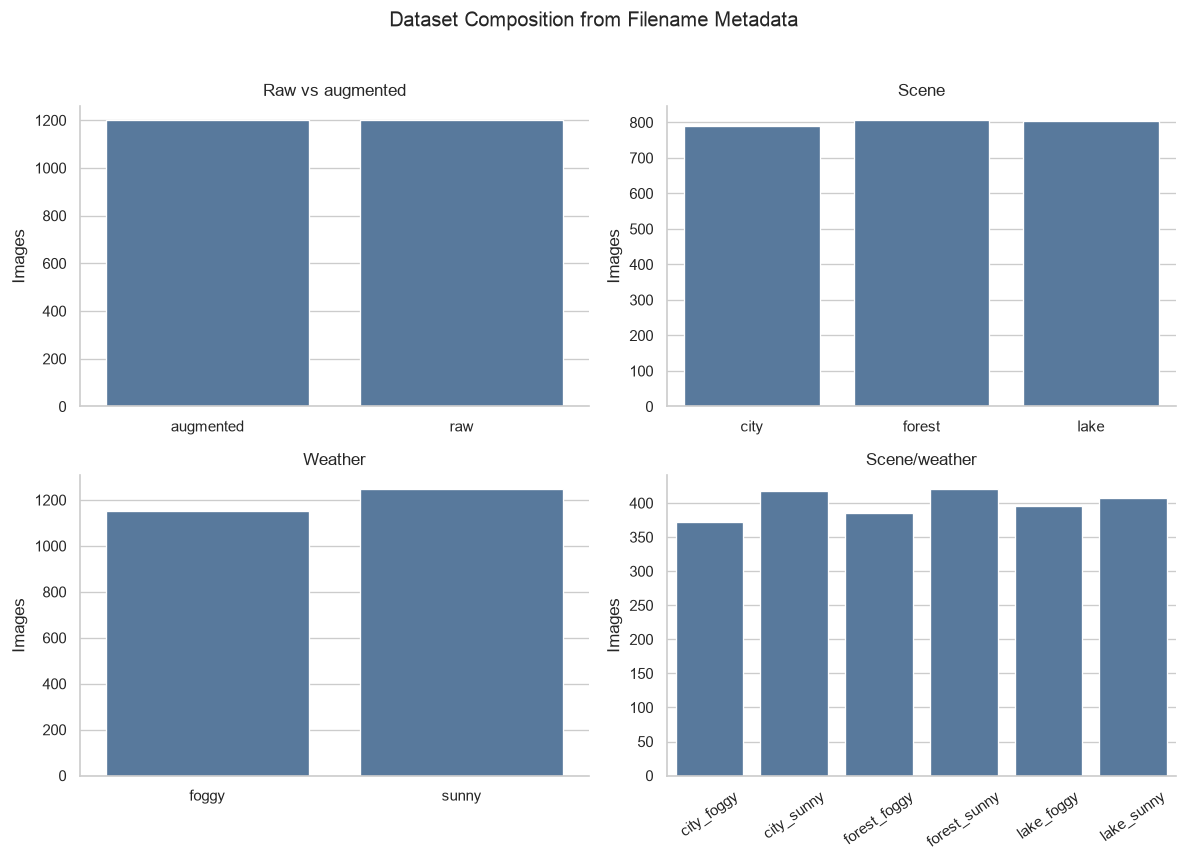

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
plot_specs = [
    ("raw_or_augmented", "Raw vs augmented"),
    ("scene", "Scene"),
    ("weather", "Weather"),
    ("scene_weather", "Scene/weather"),
]
for ax, (column, title) in zip(axes.ravel(), plot_specs):
    counts = images_df[column].value_counts().sort_index()
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Images")
    ax.tick_params(axis="x", rotation=35 if column == "scene_weather" else 0)
fig.suptitle("Dataset Composition from Filename Metadata", y=1.02)
fig.tight_layout()
save_figure(fig, "dataset_composition")
plt.show()

## 5. Image Characteristics

In [8]:
image_characteristics = pd.DataFrame([
    {"metric": "unique resolutions", "value": images_df[["image_width", "image_height"]].drop_duplicates().shape[0]},
    {"metric": "minimum width", "value": images_df["image_width"].min()},
    {"metric": "maximum width", "value": images_df["image_width"].max()},
    {"metric": "minimum height", "value": images_df["image_height"].min()},
    {"metric": "maximum height", "value": images_df["image_height"].max()},
    {"metric": "unique aspect ratios", "value": images_df["aspect_ratio"].nunique()},
    {"metric": "RGBA images", "value": int((images_df["image_mode"] == "RGBA").sum())},
    {"metric": "RGB images", "value": int((images_df["image_mode"] == "RGB").sum())},
    {"metric": "RGBA images with fully opaque alpha", "value": int((images_df["alpha_extrema"].astype(str) == "(255, 255)").sum())},
])

display_df(image_characteristics, "Image characteristics")
display_df(images_df.groupby(["raw_or_augmented", "image_mode"]).size().rename("image_count").reset_index(), "Image mode by raw/augmented")
display_df(images_df[["image_width", "image_height", "aspect_ratio"]].value_counts().rename("image_count").reset_index(), "Resolution/aspect ratio counts")

**Image characteristics**

,metric,value
0,unique resolutions,1
1,minimum width,2560
2,maximum width,2560
3,minimum height,1440
4,maximum height,1440
5,unique aspect ratios,1
6,RGBA images,1200
7,RGB images,1200
8,RGBA images with fully opaque alpha,1200


**Image mode by raw/augmented**

,raw_or_augmented,image_mode,image_count
0,augmented,RGB,1200
1,raw,RGBA,1200


**Resolution/aspect ratio counts**

,image_width,image_height,aspect_ratio,image_count
0,2560,1440,1.777778,2400


saved: reports/figures/image_characteristics.png


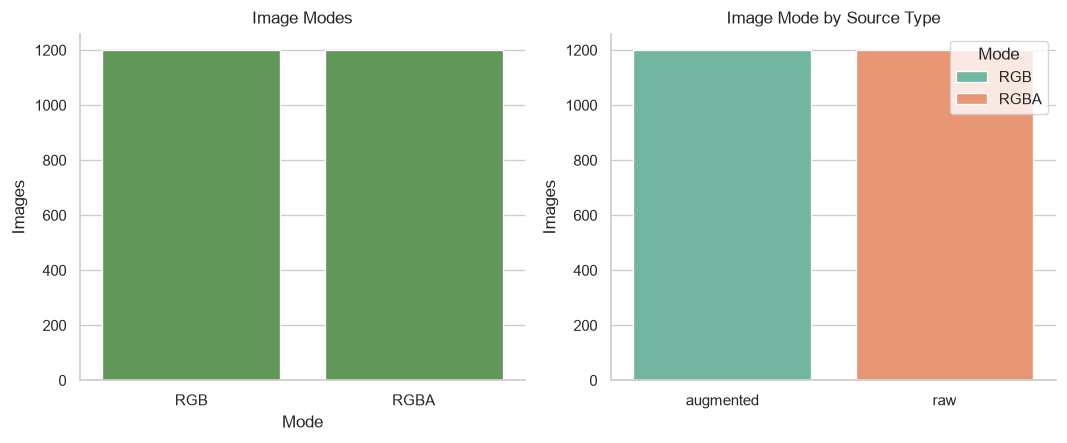

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
mode_counts = images_df["image_mode"].value_counts().sort_index()
sns.barplot(x=mode_counts.index, y=mode_counts.values, ax=axes[0], color="#59A14F")
axes[0].set_title("Image Modes")
axes[0].set_ylabel("Images")
axes[0].set_xlabel("Mode")

mode_by_source = images_df.groupby(["raw_or_augmented", "image_mode"]).size().reset_index(name="image_count")
sns.barplot(data=mode_by_source, x="raw_or_augmented", y="image_count", hue="image_mode", ax=axes[1], palette="Set2")
axes[1].set_title("Image Mode by Source Type")
axes[1].set_ylabel("Images")
axes[1].set_xlabel("")
axes[1].legend(title="Mode")
fig.tight_layout()
save_figure(fig, "image_characteristics")
plt.show()

## 6. Bounding-Box Analysis

Small-object thresholds below are descriptive analysis thresholds, not semantic class definitions.

In [10]:
bbox_columns = [
    "width_px", "height_px", "area_px", "relative_area", "bbox_aspect_ratio",
    "x_center_norm", "y_center_norm", "x_min_norm", "y_min_norm", "x_max_norm", "y_max_norm",
]

bbox_summary = pd.DataFrame({column: percentile_summary(annotations_df[column]) for column in bbox_columns}).T
bbox_summary = bbox_summary[["min", "p01", "p05", "p25", "p50", "p75", "p95", "p99", "mean", "max"]]
display_df(bbox_summary, "Bounding-box summary with percentiles")

small_object_rows = []
for threshold in [8, 16, 32, 64]:
    either_dim = (annotations_df["width_px"] < threshold) | (annotations_df["height_px"] < threshold)
    both_dims = (annotations_df["width_px"] < threshold) & (annotations_df["height_px"] < threshold)
    small_object_rows.append({
        "threshold_px": threshold,
        "objects_either_dimension_below_threshold": int(either_dim.sum()),
        "pct_either_dimension_below_threshold": either_dim.mean() * 100,
        "objects_both_dimensions_below_threshold": int(both_dims.sum()),
        "pct_both_dimensions_below_threshold": both_dims.mean() * 100,
    })
small_object_df = pd.DataFrame(small_object_rows)
display_df(small_object_df, "Descriptive small-object threshold counts")

**Bounding-box summary with percentiles**

,min,p01,p05,p25,p50,p75,p95,p99,mean,max
width_px,9.000960,16.000000,25.000960,40.000000,52.999680,68.999680,107.000320,140.011264,57.424196,196.001280
height_px,11.000160,15.999840,22.999680,36.000000,45.000000,58.000320,92.000160,127.009368,49.520627,195.999840
area_px,252.021119,540.011059,839.980800,1478.997600,2249.971200,3618.272880,9030.944304,14022.174587,3132.093768,33345.144480
relative_area,0.000068,0.000146,0.000228,0.000401,0.000610,0.000982,0.002450,0.003804,0.000850,0.009045
bbox_aspect_ratio,0.117746,0.202486,0.292983,0.492186,0.646571,0.857801,1.434529,1.968770,0.718613,2.849861
x_center_norm,0.024219,0.085740,0.172266,0.392139,0.554102,0.662012,0.812901,0.905088,0.532923,0.966797
y_center_norm,0.051042,0.087497,0.146528,0.285330,0.385069,0.527778,0.703836,0.850000,0.406832,0.953819
x_min_norm,0.000000,0.071484,0.161329,0.383985,0.542188,0.649707,0.801621,0.887891,0.521707,0.946094
y_min_norm,0.020139,0.074994,0.130556,0.270833,0.370139,0.508507,0.681285,0.817368,0.389637,0.916667
x_max_norm,0.047656,0.103117,0.182792,0.400293,0.567968,0.676368,0.823907,0.919922,0.544139,0.987500


**Descriptive small-object threshold counts**

,threshold_px,objects_either_dimension_below_threshold,pct_either_dimension_below_threshold,objects_both_dimensions_below_threshold,pct_both_dimensions_below_threshold
0,8,0,0.000000,0,0.000000
1,16,97,2.020833,0,0.000000
2,32,1364,28.416667,88,1.833333
3,64,4179,87.062500,3016,62.833333


saved: reports/figures/bbox_distributions.png


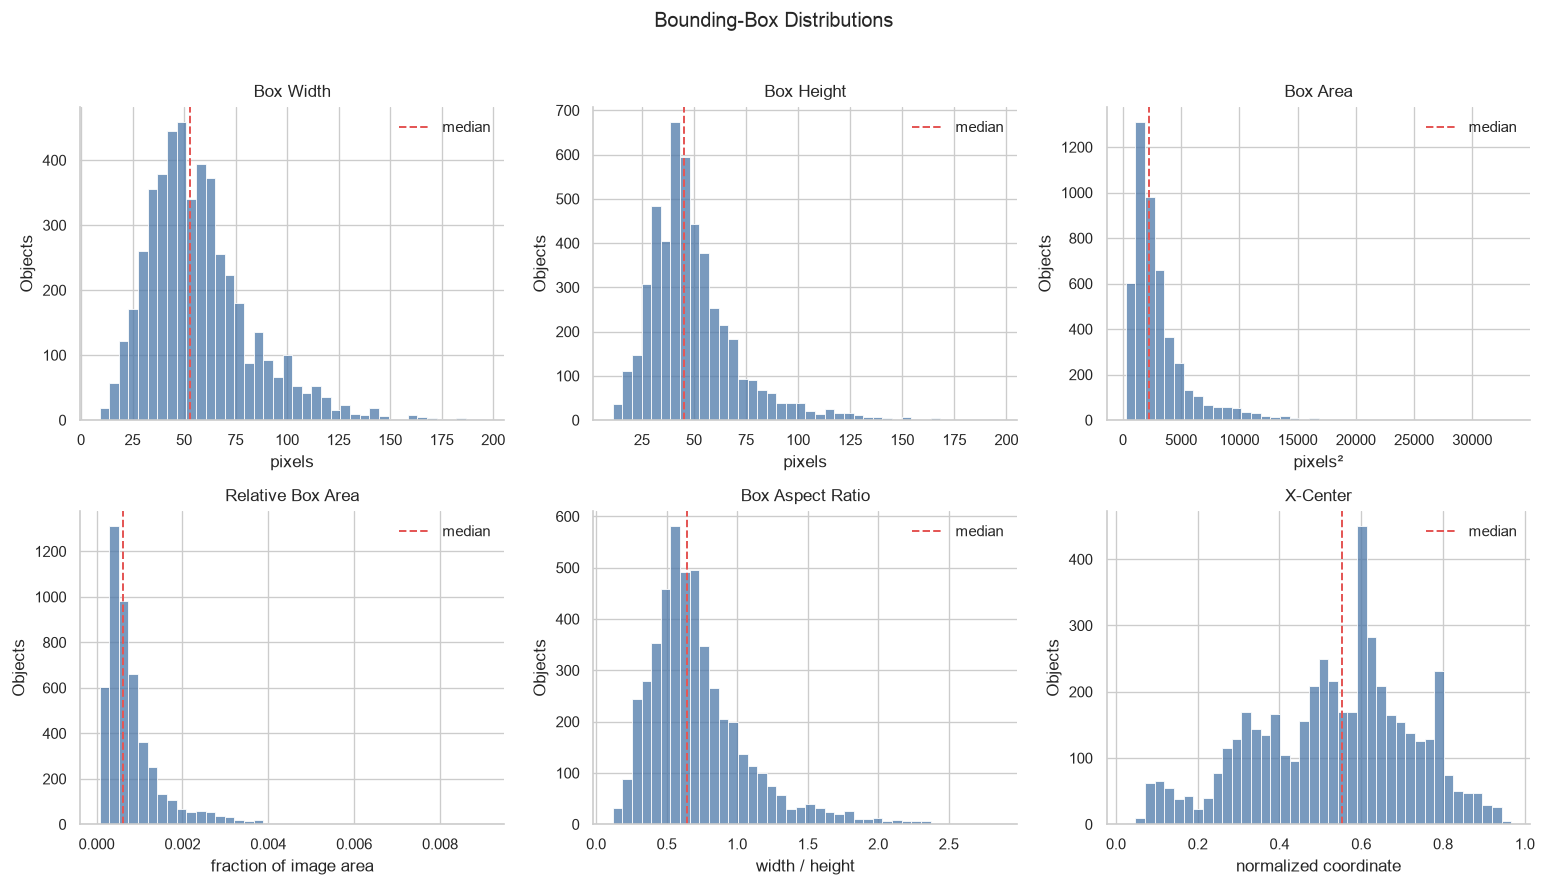

saved: reports/figures/bbox_center_distributions.png


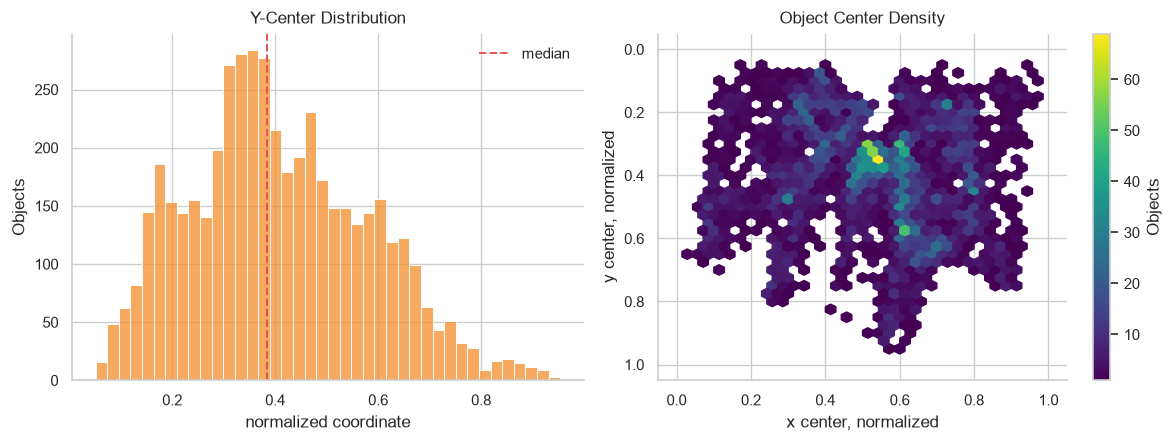

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.2))
plot_data = [
    ("width_px", "Box Width", "pixels"),
    ("height_px", "Box Height", "pixels"),
    ("area_px", "Box Area", "pixels²"),
    ("relative_area", "Relative Box Area", "fraction of image area"),
    ("bbox_aspect_ratio", "Box Aspect Ratio", "width / height"),
    ("x_center_norm", "X-Center", "normalized coordinate"),
]
for ax, (column, title, xlabel) in zip(axes.ravel(), plot_data):
    sns.histplot(annotations_df[column], bins=40, ax=ax, color="#4C78A8", edgecolor="white")
    ax.axvline(annotations_df[column].median(), color="#E45756", linestyle="--", linewidth=1.2, label="median")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Objects")
    ax.legend(frameon=False)
fig.suptitle("Bounding-Box Distributions", y=1.02)
fig.tight_layout()
save_figure(fig, "bbox_distributions")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
sns.histplot(annotations_df["y_center_norm"], bins=40, ax=axes[0], color="#F28E2B", edgecolor="white")
axes[0].axvline(annotations_df["y_center_norm"].median(), color="#E45756", linestyle="--", linewidth=1.2, label="median")
axes[0].set_title("Y-Center Distribution")
axes[0].set_xlabel("normalized coordinate")
axes[0].set_ylabel("Objects")
axes[0].legend(frameon=False)

hb = axes[1].hexbin(
    annotations_df["x_center_norm"],
    annotations_df["y_center_norm"],
    gridsize=35,
    extent=(0, 1, 0, 1),
    cmap="viridis",
    mincnt=1,
)
axes[1].set_title("Object Center Density")
axes[1].set_xlabel("x center, normalized")
axes[1].set_ylabel("y center, normalized")
axes[1].invert_yaxis()
fig.colorbar(hb, ax=axes[1], label="Objects")
fig.tight_layout()
save_figure(fig, "bbox_center_distributions")
plt.show()

## 7. Resize Impact Analysis

This section estimates object scale after resizing the full source image to candidate model input resolutions. Source images are not modified.

In [12]:
candidate_resolutions = [(2560, 1440), (1280, 720), (960, 540), (640, 360)]
resize_rows = []

for target_width, target_height in candidate_resolutions:
    scale_x = target_width / annotations_df["image_width"].astype(float)
    scale_y = target_height / annotations_df["image_height"].astype(float)
    scaled_width = annotations_df["width_px"] * scale_x
    scaled_height = annotations_df["height_px"] * scale_y

    row = {
        "target_resolution": f"{target_width}x{target_height}",
        "target_width": target_width,
        "target_height": target_height,
        "median_width_px": scaled_width.median(),
        "median_height_px": scaled_height.median(),
    }
    for threshold in [32, 16, 8]:
        below = (scaled_width < threshold) | (scaled_height < threshold)
        row[f"pct_either_dimension_lt_{threshold}px"] = below.mean() * 100
        row[f"count_either_dimension_lt_{threshold}px"] = int(below.sum())
    resize_rows.append(row)

resize_impact_df = pd.DataFrame(resize_rows)
display_df(resize_impact_df, "Estimated bounding-box scale after candidate full-image resizing")

**Estimated bounding-box scale after candidate full-image resizing**

,target_resolution,target_width,target_height,median_width_px,median_height_px,pct_either_dimension_lt_32px,count_either_dimension_lt_32px,pct_either_dimension_lt_16px,count_either_dimension_lt_16px,pct_either_dimension_lt_8px,count_either_dimension_lt_8px
0,2560x1440,2560,1440,52.99968,45.000,28.416667,1364,2.020833,97,0.000000,0
1,1280x720,1280,720,26.49984,22.500,87.062500,4179,28.416667,1364,2.020833,97
2,960x540,960,540,19.87488,16.875,95.604167,4589,55.791667,2678,6.604167,317
3,640x360,640,360,13.24992,11.250,99.541667,4778,87.062500,4179,28.416667,1364


saved: reports/figures/resize_impact.png


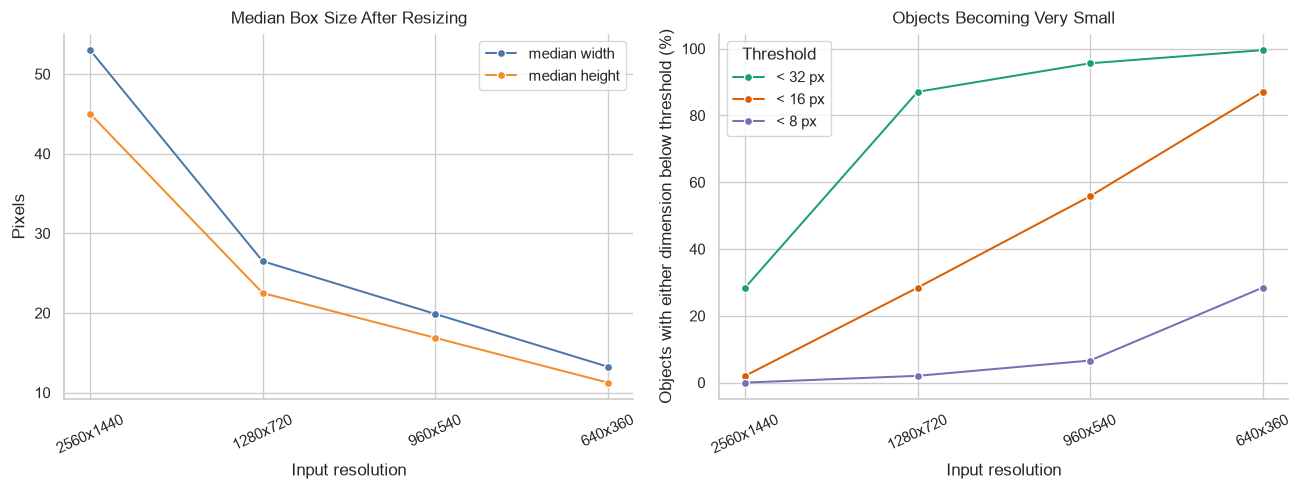

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

melted_medians = resize_impact_df.melt(
    id_vars="target_resolution",
    value_vars=["median_width_px", "median_height_px"],
    var_name="measurement",
    value_name="median_pixels",
)
melted_medians["measurement"] = melted_medians["measurement"].replace({
    "median_width_px": "median width",
    "median_height_px": "median height",
})
sns.lineplot(
    data=melted_medians,
    x="target_resolution",
    y="median_pixels",
    hue="measurement",
    marker="o",
    ax=axes[0],
    palette=["#4C78A8", "#F28E2B"],
)
axes[0].set_title("Median Box Size After Resizing")
axes[0].set_xlabel("Input resolution")
axes[0].set_ylabel("Pixels")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(title="")

threshold_cols = [
    "pct_either_dimension_lt_32px",
    "pct_either_dimension_lt_16px",
    "pct_either_dimension_lt_8px",
]
threshold_melted = resize_impact_df.melt(
    id_vars="target_resolution",
    value_vars=threshold_cols,
    var_name="threshold",
    value_name="objects_percent",
)
threshold_melted["threshold"] = threshold_melted["threshold"].str.extract(r"lt_(\d+)px")[0].map(lambda x: f"< {x} px")
sns.lineplot(
    data=threshold_melted,
    x="target_resolution",
    y="objects_percent",
    hue="threshold",
    marker="o",
    ax=axes[1],
    palette="Dark2",
)
axes[1].set_title("Objects Becoming Very Small")
axes[1].set_xlabel("Input resolution")
axes[1].set_ylabel("Objects with either dimension below threshold (%)")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(title="Threshold")
fig.tight_layout()
save_figure(fig, "resize_impact")
plt.show()

## 8. Visual Dataset Inspection

The following helpers draw labels as `drone` because only class ID `0` is present. Grids are intentionally modest to avoid producing oversized notebook outputs.

In [14]:
def load_annotation_rows_for_stem(stem: str) -> pd.DataFrame:
    return annotations_df[annotations_df["stem"] == stem].copy()


def draw_annotated_image(
    image_path: Path,
    rows: pd.DataFrame,
    *,
    target_width: int = 520,
    label: str | None = None,
) -> Image.Image:
    image = Image.open(image_path).convert("RGB")
    original_width, original_height = image.size
    target_height = int(round(original_height * target_width / original_width))
    image = image.resize((target_width, target_height), Image.Resampling.LANCZOS)
    draw = ImageDraw.Draw(image)

    try:
        font = ImageFont.truetype("Arial.ttf", 14)
    except Exception:
        font = ImageFont.load_default()

    scale_x = target_width / original_width
    scale_y = target_height / original_height

    for _, row in rows.iterrows():
        x0 = row["x_min_px"] * scale_x
        y0 = row["y_min_px"] * scale_y
        x1 = row["x_max_px"] * scale_x
        y1 = row["y_max_px"] * scale_y
        draw.rectangle([x0, y0, x1, y1], outline=(255, 45, 85), width=3)
        text = "drone"
        text_bbox = draw.textbbox((x0, y0), text, font=font)
        text_width = text_bbox[2] - text_bbox[0]
        text_height = text_bbox[3] - text_bbox[1]
        text_y = max(0, y0 - text_height - 4)
        draw.rectangle([x0, text_y, x0 + text_width + 6, text_y + text_height + 4], fill=(255, 45, 85))
        draw.text((x0 + 3, text_y + 2), text, fill="white", font=font)

    if label:
        pad = 32
        canvas = Image.new("RGB", (target_width, target_height + pad), "white")
        canvas.paste(image, (0, 0))
        draw = ImageDraw.Draw(canvas)
        draw.text((6, target_height + 8), label[:90], fill="black", font=font)
        image = canvas

    return image


def make_grid(stems: list[str], title: str, output_name: str, *, columns: int = 3, target_width: int = 420) -> None:
    panels = []
    for stem in stems:
        image_path = Path(images_df.loc[images_df["stem"] == stem, "image_path"].iloc[0])
        rows = load_annotation_rows_for_stem(stem)
        metadata = images_df.loc[images_df["stem"] == stem].iloc[0]
        label = f"{metadata['raw_or_augmented']} | {metadata['scene_weather']} | {metadata['capture_pair']} | seq {metadata['sequence_index']}"
        panels.append(draw_annotated_image(image_path, rows, target_width=target_width, label=label))

    if not panels:
        print(f"No panels for {title}")
        return

    panel_width = max(panel.width for panel in panels)
    panel_height = max(panel.height for panel in panels)
    rows_n = math.ceil(len(panels) / columns)
    title_height = 38
    grid = Image.new("RGB", (columns * panel_width, rows_n * panel_height + title_height), "white")
    draw = ImageDraw.Draw(grid)
    try:
        title_font = ImageFont.truetype("Arial.ttf", 20)
    except Exception:
        title_font = ImageFont.load_default()
    draw.text((8, 8), title, fill="black", font=title_font)

    for idx, panel in enumerate(panels):
        x = (idx % columns) * panel_width
        y = title_height + (idx // columns) * panel_height
        grid.paste(panel, (x, y))

    output_path = FIGURE_DIR / f"{output_name}.png"
    grid.save(output_path)
    print(f"saved: {output_path.relative_to(PROJECT_ROOT)}")
    display(grid)

saved: reports/figures/samples_random_annotated.png


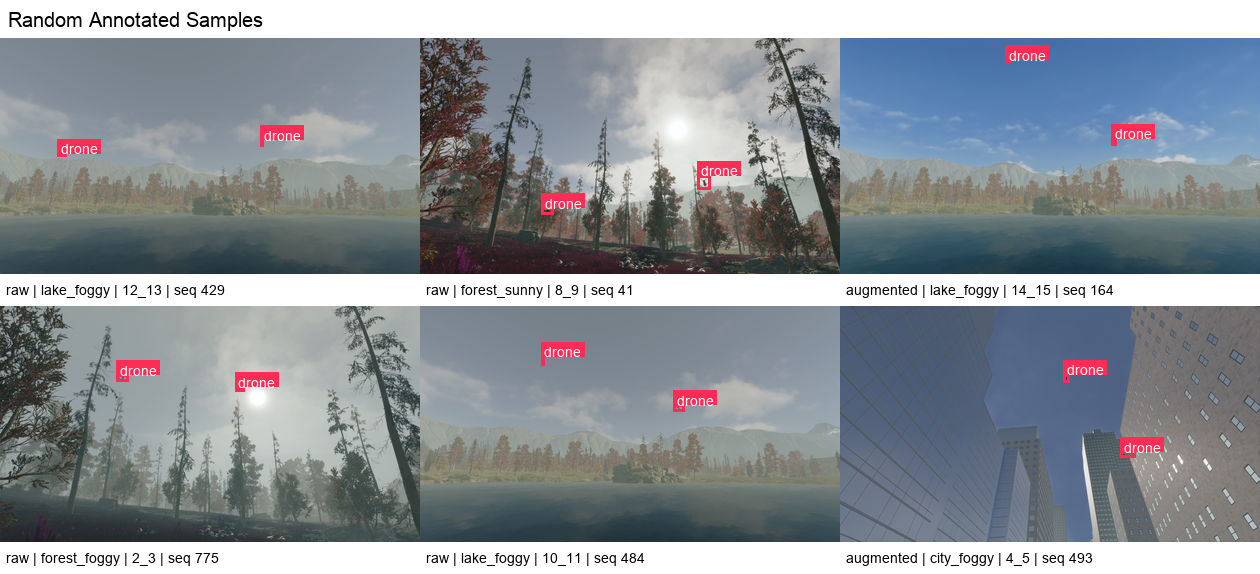

saved: reports/figures/samples_smallest_boxes.png


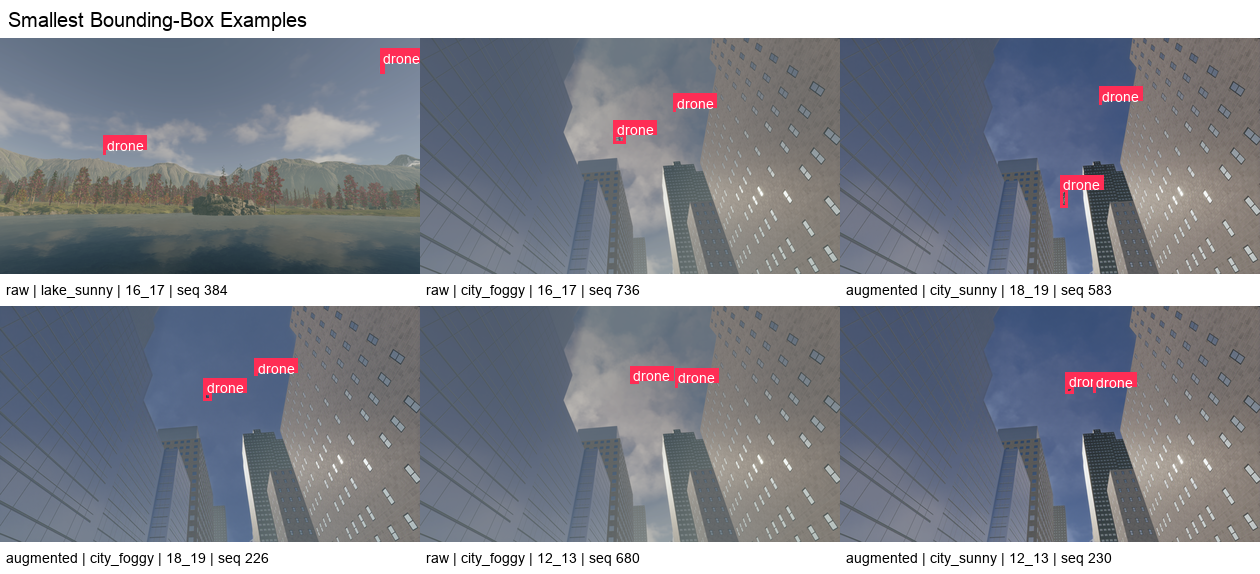

saved: reports/figures/samples_largest_boxes.png


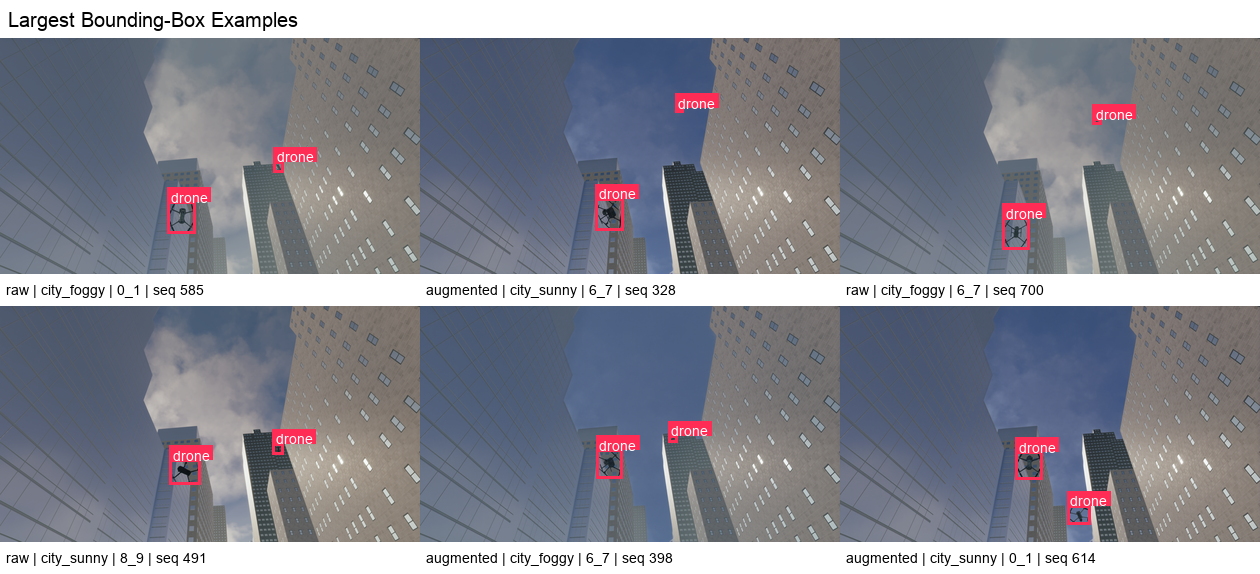

In [15]:
rng = np.random.default_rng(SEED)
random_stems = images_df.sample(n=min(6, len(images_df)), random_state=SEED)["stem"].tolist()
smallest_stems = annotations_df.nsmallest(6, "area_px")["stem"].drop_duplicates().tolist()
largest_stems = annotations_df.nlargest(6, "area_px")["stem"].drop_duplicates().tolist()

# If duplicate stems reduce the list, top up deterministically.
def top_up_stems(stems: list[str], ordered_candidates: pd.Series, n: int = 6) -> list[str]:
    seen = set(stems)
    for stem in ordered_candidates:
        if stem not in seen:
            stems.append(stem)
            seen.add(stem)
        if len(stems) >= n:
            break
    return stems[:n]

smallest_stems = top_up_stems(smallest_stems, annotations_df.sort_values("area_px")["stem"], n=6)
largest_stems = top_up_stems(largest_stems, annotations_df.sort_values("area_px", ascending=False)["stem"], n=6)

make_grid(random_stems, "Random Annotated Samples", "samples_random_annotated", columns=3, target_width=420)
make_grid(smallest_stems, "Smallest Bounding-Box Examples", "samples_smallest_boxes", columns=3, target_width=420)
make_grid(largest_stems, "Largest Bounding-Box Examples", "samples_largest_boxes", columns=3, target_width=420)

saved: reports/figures/samples_representative_conditions.png


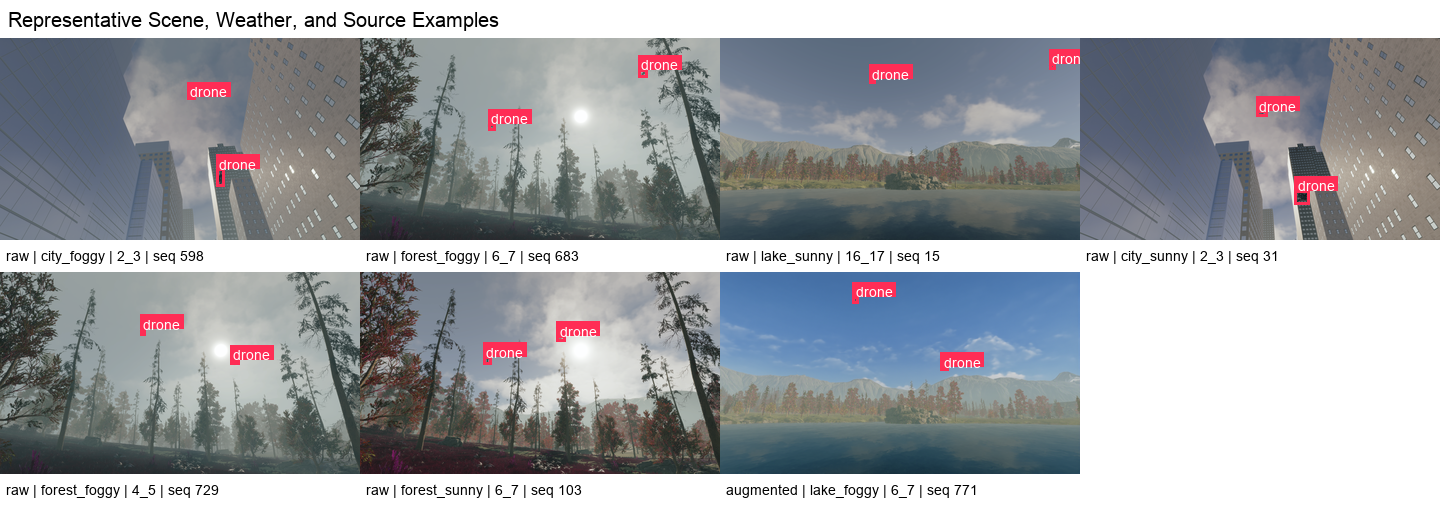

In [16]:
representative_stems = []
for column, values in [
    ("scene", ["city", "forest", "lake"]),
    ("weather", ["sunny", "foggy"]),
    ("raw_or_augmented", ["raw", "augmented"]),
]:
    for value in values:
        subset = images_df[images_df[column] == value]
        if not subset.empty:
            representative_stems.append(subset.sample(n=1, random_state=SEED + len(representative_stems))["stem"].iloc[0])

representative_stems = list(dict.fromkeys(representative_stems))[:8]
make_grid(representative_stems, "Representative Scene, Weather, and Source Examples", "samples_representative_conditions", columns=4, target_width=360)

## 9. Raw/Augmented Relationship Analysis

A raw/augmented pair is considered filename-paired only when an augmented stem becomes an existing raw stem after removing the leading `augmented_` prefix. This is conservative and does not infer looser relationships.

In [17]:
raw_stems = set(images_df.loc[images_df["raw_or_augmented"] == "raw", "stem"])
augmented_df = images_df[images_df["raw_or_augmented"] == "augmented"].copy()
augmented_df["paired_raw_stem"] = augmented_df["canonical_raw_stem"].where(augmented_df["canonical_raw_stem"].isin(raw_stems), pd.NA)
paired_augmented = augmented_df.dropna(subset=["paired_raw_stem"]).copy()

pair_rows = []
for _, aug_row in paired_augmented.iterrows():
    aug_stem = aug_row["stem"]
    raw_stem = aug_row["paired_raw_stem"]
    aug_label = (DATASET_DIR / f"{aug_stem}.txt").read_text(encoding="utf-8", errors="replace")
    raw_label = (DATASET_DIR / f"{raw_stem}.txt").read_text(encoding="utf-8", errors="replace")
    pair_rows.append({
        "augmented_stem": aug_stem,
        "raw_stem": raw_stem,
        "identical_label_text": aug_label == raw_label,
        "augmented_image_path": DATASET_DIR / f"{aug_stem}.png",
        "raw_image_path": DATASET_DIR / f"{raw_stem}.png",
    })

pairs_df = pd.DataFrame(pair_rows)

pair_summary = pd.DataFrame([
    {"metric": "raw images", "value": len(raw_stems)},
    {"metric": "augmented images", "value": len(augmented_df)},
    {"metric": "filename-paired augmented images", "value": len(pairs_df)},
    {"metric": "paired files with identical label text", "value": int(pairs_df["identical_label_text"].sum()) if not pairs_df.empty else 0},
])
display_df(pair_summary, "Raw/augmented filename-pair summary")
if not pairs_df.empty:
    display_df(pairs_df[["augmented_stem", "raw_stem", "identical_label_text"]].head(20), "Example filename pairs")
else:
    display(Markdown("No exact filename pairs found under the conservative prefix-removal rule."))

**Raw/augmented filename-pair summary**

,metric,value
0,raw images,1200
1,augmented images,1200
2,filename-paired augmented images,44
3,paired files with identical label text,44


**Example filename pairs**

,augmented_stem,raw_stem,identical_label_text
0,augmented_raw_dataset_city_foggy_city_foggy_10...,raw_dataset_city_foggy_city_foggy_10_11_sequen...,True
1,augmented_raw_dataset_city_foggy_city_foggy_12...,raw_dataset_city_foggy_city_foggy_12_13_sequen...,True
2,augmented_raw_dataset_city_foggy_city_foggy_14...,raw_dataset_city_foggy_city_foggy_14_15_sequen...,True
3,augmented_raw_dataset_city_foggy_city_foggy_6_...,raw_dataset_city_foggy_city_foggy_6_7_sequence...,True
4,augmented_raw_dataset_city_foggy_city_foggy_8_...,raw_dataset_city_foggy_city_foggy_8_9_sequence...,True
5,augmented_raw_dataset_city_sunny_city_sunny_0_...,raw_dataset_city_sunny_city_sunny_0_1_sequence...,True
6,augmented_raw_dataset_city_sunny_city_sunny_0_...,raw_dataset_city_sunny_city_sunny_0_1_sequence...,True
7,augmented_raw_dataset_city_sunny_city_sunny_14...,raw_dataset_city_sunny_city_sunny_14_15_sequen...,True
8,augmented_raw_dataset_city_sunny_city_sunny_14...,raw_dataset_city_sunny_city_sunny_14_15_sequen...,True
9,augmented_raw_dataset_city_sunny_city_sunny_16...,raw_dataset_city_sunny_city_sunny_16_17_sequen...,True


**Lightweight thumbnail similarity for filename-paired raw/augmented images**

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
thumbnail_mae,44.0,0.044539,0.009900,0.034259,0.034374,0.034613,0.037166,0.039804,0.055235,0.061939,0.062285,0.062410
thumbnail_rmse,44.0,0.072739,0.007858,0.056798,0.056920,0.057338,0.071463,0.073714,0.077047,0.083119,0.083609,0.083619
thumbnail_correlation,44.0,0.851459,0.086337,0.683365,0.686963,0.696694,0.793565,0.843318,0.960170,0.965465,0.965989,0.966154


saved: reports/figures/raw_augmented_pair_similarity.png


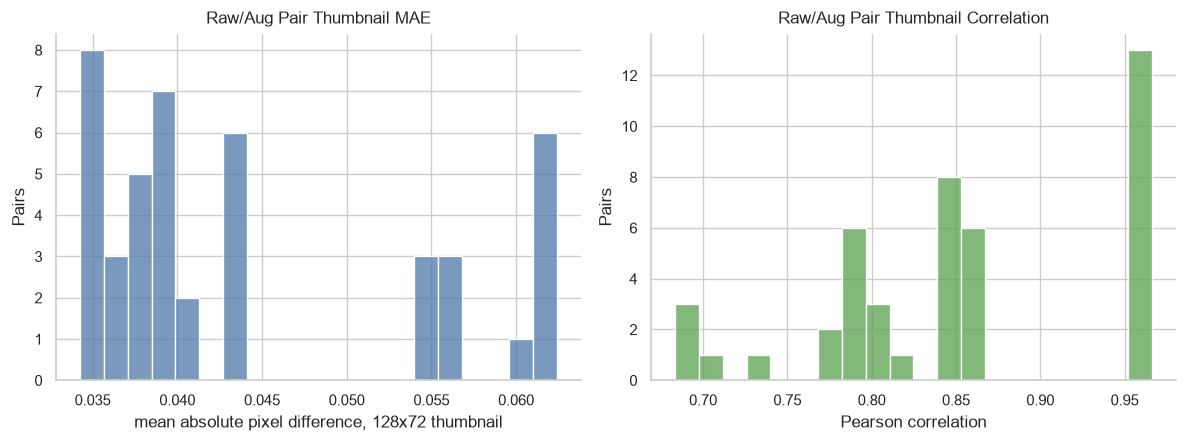

In [18]:
def image_thumbnail_array(path: Path, size=(128, 72)) -> np.ndarray:
    with Image.open(path) as image:
        image = ImageOps.exif_transpose(image).convert("RGB").resize(size, Image.Resampling.BILINEAR)
        return np.asarray(image, dtype=np.float32) / 255.0

similarity_rows = []
for _, row in pairs_df.iterrows():
    raw_arr = image_thumbnail_array(Path(row["raw_image_path"]))
    aug_arr = image_thumbnail_array(Path(row["augmented_image_path"]))
    diff = raw_arr - aug_arr
    mae = np.abs(diff).mean()
    rmse = np.sqrt(np.square(diff).mean())
    raw_flat = raw_arr.reshape(-1)
    aug_flat = aug_arr.reshape(-1)
    corr = np.corrcoef(raw_flat, aug_flat)[0, 1] if raw_flat.std() > 0 and aug_flat.std() > 0 else np.nan
    similarity_rows.append({
        "raw_stem": row["raw_stem"],
        "augmented_stem": row["augmented_stem"],
        "thumbnail_mae": mae,
        "thumbnail_rmse": rmse,
        "thumbnail_correlation": corr,
        "identical_label_text": row["identical_label_text"],
    })

pair_similarity_df = pd.DataFrame(similarity_rows)
if not pair_similarity_df.empty:
    display_df(pair_similarity_df[["thumbnail_mae", "thumbnail_rmse", "thumbnail_correlation"]].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T, "Lightweight thumbnail similarity for filename-paired raw/augmented images")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    sns.histplot(pair_similarity_df["thumbnail_mae"], bins=20, ax=axes[0], color="#4C78A8", edgecolor="white")
    axes[0].set_title("Raw/Aug Pair Thumbnail MAE")
    axes[0].set_xlabel("mean absolute pixel difference, 128x72 thumbnail")
    axes[0].set_ylabel("Pairs")

    sns.histplot(pair_similarity_df["thumbnail_correlation"], bins=20, ax=axes[1], color="#59A14F", edgecolor="white")
    axes[1].set_title("Raw/Aug Pair Thumbnail Correlation")
    axes[1].set_xlabel("Pearson correlation")
    axes[1].set_ylabel("Pairs")
    fig.tight_layout()
    save_figure(fig, "raw_augmented_pair_similarity")
    plt.show()
else:
    display(Markdown("No exact filename pairs were available for thumbnail similarity analysis."))

saved: reports/figures/samples_raw_augmented_pairs.png


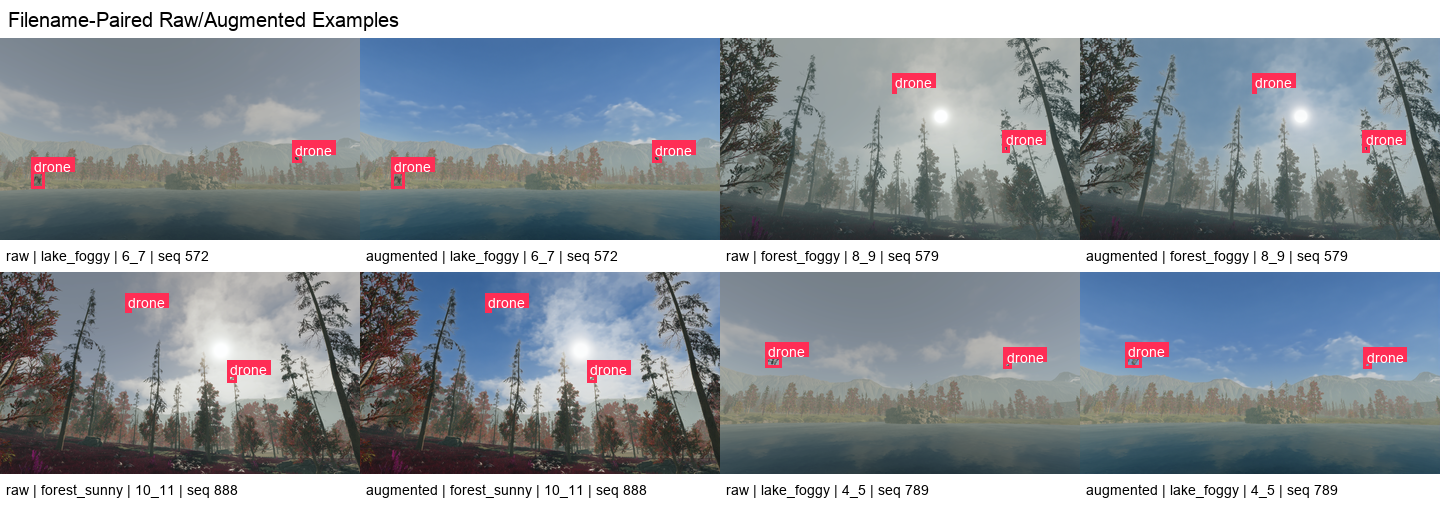

In [19]:
if not pairs_df.empty:
    sample_pairs = pairs_df.sample(n=min(4, len(pairs_df)), random_state=SEED).reset_index(drop=True)
    panels = []
    for _, row in sample_pairs.iterrows():
        panels.append((row["raw_stem"], "raw"))
        panels.append((row["augmented_stem"], "augmented"))

    paired_stems = [stem for stem, _ in panels]
    make_grid(paired_stems, "Filename-Paired Raw/Augmented Examples", "samples_raw_augmented_pairs", columns=4, target_width=360)

## 10. Sequence / Group Structure Investigation

This section looks for evidence that filenames encode related captures, sequences, simulation conditions, or other groupable units. No final split is created here.

In [20]:
group_columns = ["scene", "weather", "scene_weather", "capture_pair", "candidate_group_key", "sequence_index", "step"]
for column in group_columns:
    counts = images_df[column].value_counts(dropna=False)
    print(f"{column}: unique values = {counts.shape[0]}")
    display(counts.head(15).rename_axis(column).reset_index(name="image_count"))

candidate_group_counts = images_df["candidate_group_key"].value_counts().sort_index()
candidate_group_summary = candidate_group_counts.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame("images_per_group")
display_df(candidate_group_summary, "Candidate grouping key size summary")

# A stricter key includes sequence_index. This identifies raw/aug counterparts and exact frame-level relationships when present.
images_df["candidate_frame_key"] = images_df.apply(
    lambda row: f"{row['scene_weather']}__capture_{row['capture_pair']}__sequence_{row['sequence_index']}__step_{row['step']}"
    if pd.notna(row["scene_weather"]) else pd.NA,
    axis=1,
)
frame_key_counts = images_df["candidate_frame_key"].value_counts()
display_df(frame_key_counts.value_counts().sort_index().rename_axis("images_per_frame_key").reset_index(name="frame_key_count"), "Candidate frame-key multiplicity")

scene: unique values = 3


,scene,image_count
0,forest,806
1,lake,804
2,city,790


weather: unique values = 2


,weather,image_count
0,sunny,1246
1,foggy,1154


scene_weather: unique values = 6


...

,step,image_count
0,0,2400


**Candidate grouping key size summary**

,images_per_group
count,60.000000
mean,40.000000
std,7.039838
min,24.000000
1%,25.770000
5%,27.950000
25%,33.750000
50%,41.000000
75%,44.250000
95%,50.000000


**Candidate frame-key multiplicity**

,images_per_frame_key,frame_key_count
0,1,2312
1,2,44


saved: reports/figures/sequence_group_structure.png


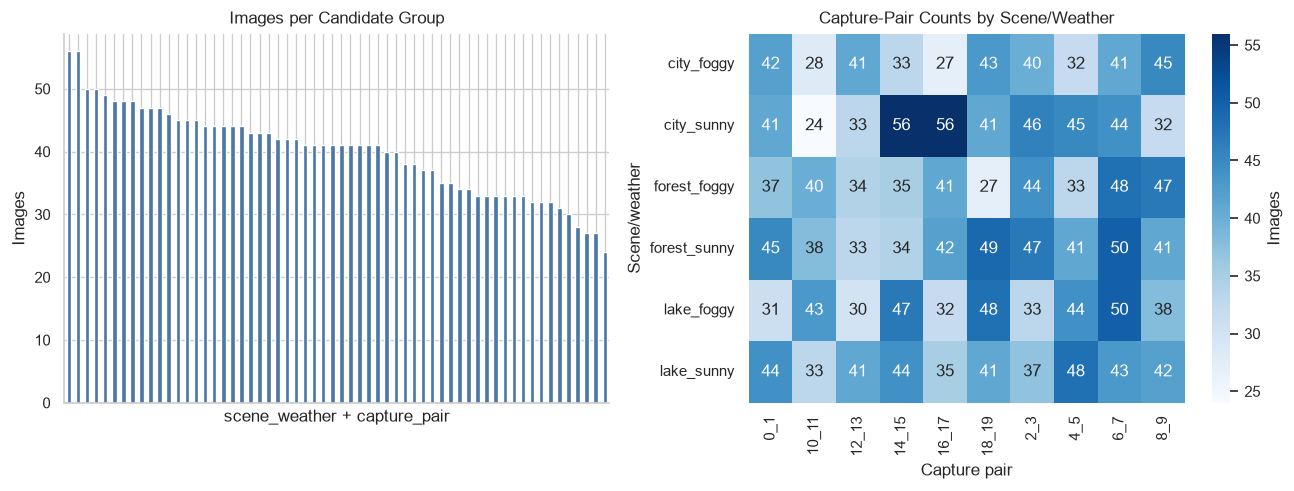

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

candidate_group_counts.sort_values(ascending=False).plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Images per Candidate Group")
axes[0].set_xlabel("scene_weather + capture_pair")
axes[0].set_ylabel("Images")
axes[0].tick_params(axis="x", labelbottom=False)

capture_counts = images_df.groupby(["scene_weather", "capture_pair"]).size().reset_index(name="image_count")
pivot = capture_counts.pivot(index="scene_weather", columns="capture_pair", values="image_count").fillna(0)
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "Images"}, ax=axes[1])
axes[1].set_title("Capture-Pair Counts by Scene/Weather")
axes[1].set_xlabel("Capture pair")
axes[1].set_ylabel("Scene/weather")
fig.tight_layout()
save_figure(fig, "sequence_group_structure")
plt.show()

## 11. Dataset Difficulty Analysis

Observed facts are separated from interpretation so that later modeling decisions remain evidence-backed.

In [22]:
difficulty_facts = {
    "total_objects": len(annotations_df),
    "classes": sorted(annotations_df["class_id"].unique().tolist()),
    "objects_per_image_values": sorted(images_df["object_count"].unique().tolist()),
    "median_box_width_px": annotations_df["width_px"].median(),
    "median_box_height_px": annotations_df["height_px"].median(),
    "median_relative_area_pct": annotations_df["relative_area"].median() * 100,
    "pct_objects_either_dim_lt_32px": (((annotations_df["width_px"] < 32) | (annotations_df["height_px"] < 32)).mean() * 100),
    "pct_objects_either_dim_lt_64px": (((annotations_df["width_px"] < 64) | (annotations_df["height_px"] < 64)).mean() * 100),
    "scene_weather_conditions": sorted(images_df["scene_weather"].dropna().unique().tolist()),
    "filename_paired_raw_augmented_images": len(pairs_df),
}

display_df(pd.DataFrame([difficulty_facts]).T.rename(columns={0: "value"}), "Evidence used for difficulty assessment")

display(Markdown(f"""
**Observed facts**

- The dataset has {difficulty_facts['total_objects']:,} labeled objects and only class ID `{difficulty_facts['classes'][0]}`.
- Every image has exactly {difficulty_facts['objects_per_image_values'][0]} annotated objects.
- Median box size is {difficulty_facts['median_box_width_px']:.1f} x {difficulty_facts['median_box_height_px']:.1f} px at the native 2560 x 1440 resolution.
- Median object area is {difficulty_facts['median_relative_area_pct']:.4f}% of the image.
- {difficulty_facts['pct_objects_either_dim_lt_32px']:.1f}% of objects have at least one dimension below 32 px at native resolution.
- Filename metadata identifies these scene/weather conditions: {', '.join(difficulty_facts['scene_weather_conditions'])}.
- Visual samples show rendered/synthetic scenes with drones often appearing as small dark silhouettes against sky, sun glare, fog, city geometry, trees, or lake horizons.

**Interpretation**

- The dominant difficulty is small-object localization rather than multi-class recognition.
- Fixed two-object cardinality and synthetic filename regularities could make evaluation deceptively easy if related frames or raw/augmented counterparts leak across splits.
- Downsampling full images too aggressively will push many boxes below common feature-map and matching thresholds.
- Since the class problem is currently single-class, evaluation should emphasize localization quality, recall on tiny objects, and condition-wise robustness.
"""))

**Evidence used for difficulty assessment**

,value
total_objects,4800
classes,[0]
objects_per_image_values,[2]
median_box_width_px,52.99968
median_box_height_px,45.0
median_relative_area_pct,0.061034
pct_objects_either_dim_lt_32px,28.416667
pct_objects_either_dim_lt_64px,87.0625
scene_weather_conditions,"[city_foggy, city_sunny, forest_foggy, forest_..."
filename_paired_raw_augmented_images,44



**Observed facts**

- The dataset has 4,800 labeled objects and only class ID `0`.
- Every image has exactly 2 annotated objects.
- Median box size is 53.0 x 45.0 px at the native 2560 x 1440 resolution.
- Median object area is 0.0610% of the image.
- 28.4% of objects have at least one dimension below 32 px at native resolution.
- Filename metadata identifies these scene/weather conditions: city_foggy, city_sunny, forest_foggy, forest_sunny, lake_foggy, lake_sunny.
- Visual samples show rendered/synthetic scenes with drones often appearing as small dark silhouettes against sky, sun glare, fog, city geometry, trees, or lake horizons.

**Interpretation**

- The dominant difficulty is small-object localization rather than multi-class recognition.
- Fixed two-object cardinality and synthetic filename regularities could make evaluation deceptively easy if related frames or raw/augmented counterparts leak across splits.
- Downsampling full images too aggressively will push many boxes below common feature-map and matching thresholds.
- Since the class problem is currently single-class, evaluation should emphasize localization quality, recall on tiny objects, and condition-wise robustness.


## 12. Conclusions and Modeling Implications

In [23]:
resize_native = resize_impact_df.loc[resize_impact_df["target_resolution"] == "2560x1440"].iloc[0]
resize_640 = resize_impact_df.loc[resize_impact_df["target_resolution"] == "640x360"].iloc[0]

conclusion_md = f"""
**Most important dataset characteristics**

- The dataset contains {len(images_df):,} PNG images and {len(annotations_df):,} drone boxes.
- All images are 2560 x 1440, 16:9.
- All labels use normalized center-based `class_id x_center y_center width height` rows.
- Only class ID `0` is present, so this is currently a single-class drone-detection dataset.
- Every image has exactly two labeled objects.
- Native median object size is {annotations_df['width_px'].median():.1f} x {annotations_df['height_px'].median():.1f} px, with median relative area {annotations_df['relative_area'].median() * 100:.4f}%.

**Potential leakage risks**

- Filenames encode scene, weather, capture-pair, sequence index, step, and raw/augmented status.
- A conservative prefix-removal rule finds {len(pairs_df):,} filename-paired raw/augmented image pairs.
- {int(pairs_df['identical_label_text'].sum()) if not pairs_df.empty else 0:,} paired files have identical label text.
- Candidate grouping keys such as `scene_weather + capture_pair` and stricter `scene_weather + capture_pair + sequence_index + step` should be considered before creating splits.

**Input-resolution implications**

- At 2560 x 1440, {resize_native['pct_either_dimension_lt_32px']:.1f}% of objects already have either width or height below 32 px.
- At 640 x 360, the median box becomes {resize_640['median_width_px']:.1f} x {resize_640['median_height_px']:.1f} px, and {resize_640['pct_either_dimension_lt_16px']:.1f}% of objects have either dimension below 16 px.
- This notebook does not choose the final model resolution, but the evidence argues that resize strategy will be a central design variable.

**Backbone and detection-head implications**

- A detector designed from scratch should preserve spatial detail and avoid excessive early downsampling.
- Detection-head resolution and assignment/loss design should explicitly account for tiny boxes.
- Because this is single-class, classification loss is likely less informative than localization/objectness behavior.

**Evaluation implications**

- Report localization-sensitive metrics and stratify results by object size, scene/weather, and potentially raw/augmented status.
- Avoid naive random splits until sequence/group leakage has been handled.
- Use condition-wise evaluation to check whether performance depends on city/forest/lake or sunny/foggy backgrounds.

**Unresolved questions**

- Whether class `0` has an official dataset-provided class name outside this folder.
- Whether non-exact raw/augmented relationships exist beyond the conservative filename pairs.
- Whether neighboring sequence indices represent temporally adjacent or independently sampled frames.
- Whether the synthetic distribution matches the intended real-world deployment domain.
"""

display(Markdown(conclusion_md))


**Most important dataset characteristics**

- The dataset contains 2,400 PNG images and 4,800 drone boxes.
- All images are 2560 x 1440, 16:9.
- All labels use normalized center-based `class_id x_center y_center width height` rows.
- Only class ID `0` is present, so this is currently a single-class drone-detection dataset.
- Every image has exactly two labeled objects.
- Native median object size is 53.0 x 45.0 px, with median relative area 0.0610%.

**Potential leakage risks**

- Filenames encode scene, weather, capture-pair, sequence index, step, and raw/augmented status.
- A conservative prefix-removal rule finds 44 filename-paired raw/augmented image pairs.
- 44 paired files have identical label text.
- Candidate grouping keys such as `scene_weather + capture_pair` and stricter `scene_weather + capture_pair + sequence_index + step` should be considered before creating splits.

**Input-resolution implications**

- At 2560 x 1440, 28.4% of objects already have either width or height below 32 px.
- At 640 x 360, the median box becomes 13.2 x 11.2 px, and 87.1% of objects have either dimension below 16 px.
- This notebook does not choose the final model resolution, but the evidence argues that resize strategy will be a central design variable.

**Backbone and detection-head implications**

- A detector designed from scratch should preserve spatial detail and avoid excessive early downsampling.
- Detection-head resolution and assignment/loss design should explicitly account for tiny boxes.
- Because this is single-class, classification loss is likely less informative than localization/objectness behavior.

**Evaluation implications**

- Report localization-sensitive metrics and stratify results by object size, scene/weather, and potentially raw/augmented status.
- Avoid naive random splits until sequence/group leakage has been handled.
- Use condition-wise evaluation to check whether performance depends on city/forest/lake or sunny/foggy backgrounds.

**Unresolved questions**

- Whether class `0` has an official dataset-provided class name outside this folder.
- Whether non-exact raw/augmented relationships exist beyond the conservative filename pairs.
- Whether neighboring sequence indices represent temporally adjacent or independently sampled frames.
- Whether the synthetic distribution matches the intended real-world deployment domain.
